# TRF Misalignment Diagnostic

Inspect temporal alignment between stimulus and EEG for **one subject, one trial**.

1. Plot the first 10 s of the envelope, EEG, and acoustic onset markers
2. Compute a within-trial normalised cross-correlation with lag restricted to ±500 ms to find the peak auditory latency without interference from slow drifts or edge artefacts


In [10]:
import sys
from pathlib import Path

# Run from musical-surprisal/TRF/
sys.path.insert(0, str(Path('.').resolve()))

import constants
import eeg_functions as eeg_func

import numpy as np
import matplotlib.pyplot as plt
from scipy.io import loadmat
from scipy.signal import correlate
from scipy.signal import resample as sp_resample
import eelbrain

%matplotlib inline
plt.rcParams.update({
    'figure.dpi': 130,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

SUBJECT               = 'Sub2'
TRIAL_IDX             = 0
SFREQ                 = 64         # Hz — matches TRF_ridge_2.py
CHANNEL_IDX           = 0          # EEG channel to inspect
PLOT_DURATION_S       = 20.0       # seconds of the trial to plot
AUDITORY_LATENCIES_MS = [80, 100, 150, 200]


In [2]:

# ── Load one trial — same preprocessing as TRF_ridge_2.py ────────────────────
# Sequence: low-pass 8 Hz → resample 64 Hz → high-pass 1 Hz
# Using the identical order matters: filtering after downsampling avoids
# aliasing and matches the pipeline whose TRF results we are diagnosing.

stim_mat     = loadmat(constants.EEG_DIR / 'dataStim.mat',
                       struct_as_record=False, squeeze_me=True)
stim         = stim_mat['stim']
stim_fs      = int(stim.fs)
stim_feature = stim.data[0, :]           # per-trial envelopes at stim_fs Hz

eeg_data = eeg_func.load_subject_raw_eeg(
    constants.EEG_DIR / f'data{SUBJECT}.mat', SUBJECT)
raw = eeg_func.create_mne_raw_from_loaded(eeg_data)   # MNE Raw at 100 Hz

raw.filter(None, constants.HIGH_FREQUENCY,
           method='fir', phase='zero', n_jobs=1)        # 1. low-pass 8 Hz
raw.resample(SFREQ)                                     # 2. 100 → 64 Hz
raw.filter(constants.LOW_FREQUENCY, None,
           method='fir', phase='zero', n_jobs=1)        # 3. high-pass 1 Hz

events = eeg_func.create_eelbrain_events(raw)

# Build envelope and acoustic onsets for every trial
envelopes = []
for i in range(len(events['event'])):
    env_raw       = np.asarray(stim_feature[i], dtype=np.float64)
    n_target      = int(round(len(env_raw) * SFREQ / stim_fs))
    env_resampled = sp_resample(env_raw, n_target)
    time_axis     = eelbrain.UTS(0, 1 / SFREQ, len(env_resampled))
    envelopes.append(eelbrain.NDVar(env_resampled, (time_axis,)))

events['envelope'] = envelopes
events['onsets']   = [env.diff('time').clip(0) for env in envelopes]
events['duration'] = eelbrain.Var([env.time.tstop for env in envelopes])
events['eeg']      = eelbrain.load.mne.variable_length_epochs(
    events, 0, tstop='duration', decim=1, adjacency='auto')

# Extract the chosen trial
i        = TRIAL_IDX
eeg_arr  = events['eeg'][i].get_data(('sensor', 'time')).T   # (T, n_ch)
envelope = events['envelope'][i].x
onsets   = events['onsets'][i].x

# Trim to equal length (resampling can produce ±1 sample discrepancy)
n        = min(eeg_arr.shape[0], len(envelope))
eeg_arr  = eeg_arr[:n]
envelope = envelope[:n]
onsets   = onsets[:n]

eeg_ch   = eeg_arr[:, CHANNEL_IDX]
t_s      = np.arange(n) / SFREQ

print(f'Subject  : {SUBJECT}   Trial: {TRIAL_IDX}')
print(f'EEG shape: {eeg_arr.shape}  (samples x channels)')
print(f'Duration : {n / SFREQ:.2f} s   Sampling rate: {SFREQ} Hz')
print(f'Onsets   : {(onsets > 0).sum()} nonzero samples  '
      f'({(onsets > 0).sum() / (n / SFREQ):.2f} events/s)')


✓ Loaded Non-musician (Subject Sub1)
  - 30 trials, 64 channels @ 512 Hz


/var/folders/r4/z65_5ryn59z3_3lyzgvxdcm40000gn/T/ipykernel_79485/1262576127.py:18: RuntimeWarning: Resampling of the stim channels caused event information to become unreliable. Consider finding events on the original data and passing the event matrix as a parameter.
  raw.resample(SFREQ)                                     # 2. 100 → 64 Hz


Subject  : Sub1   Trial: 0
EEG shape: (10172, 64)  (samples x channels)
Duration : 158.94 s   Sampling rate: 64 Hz
Onsets   : 2585 nonzero samples  (16.26 events/s)


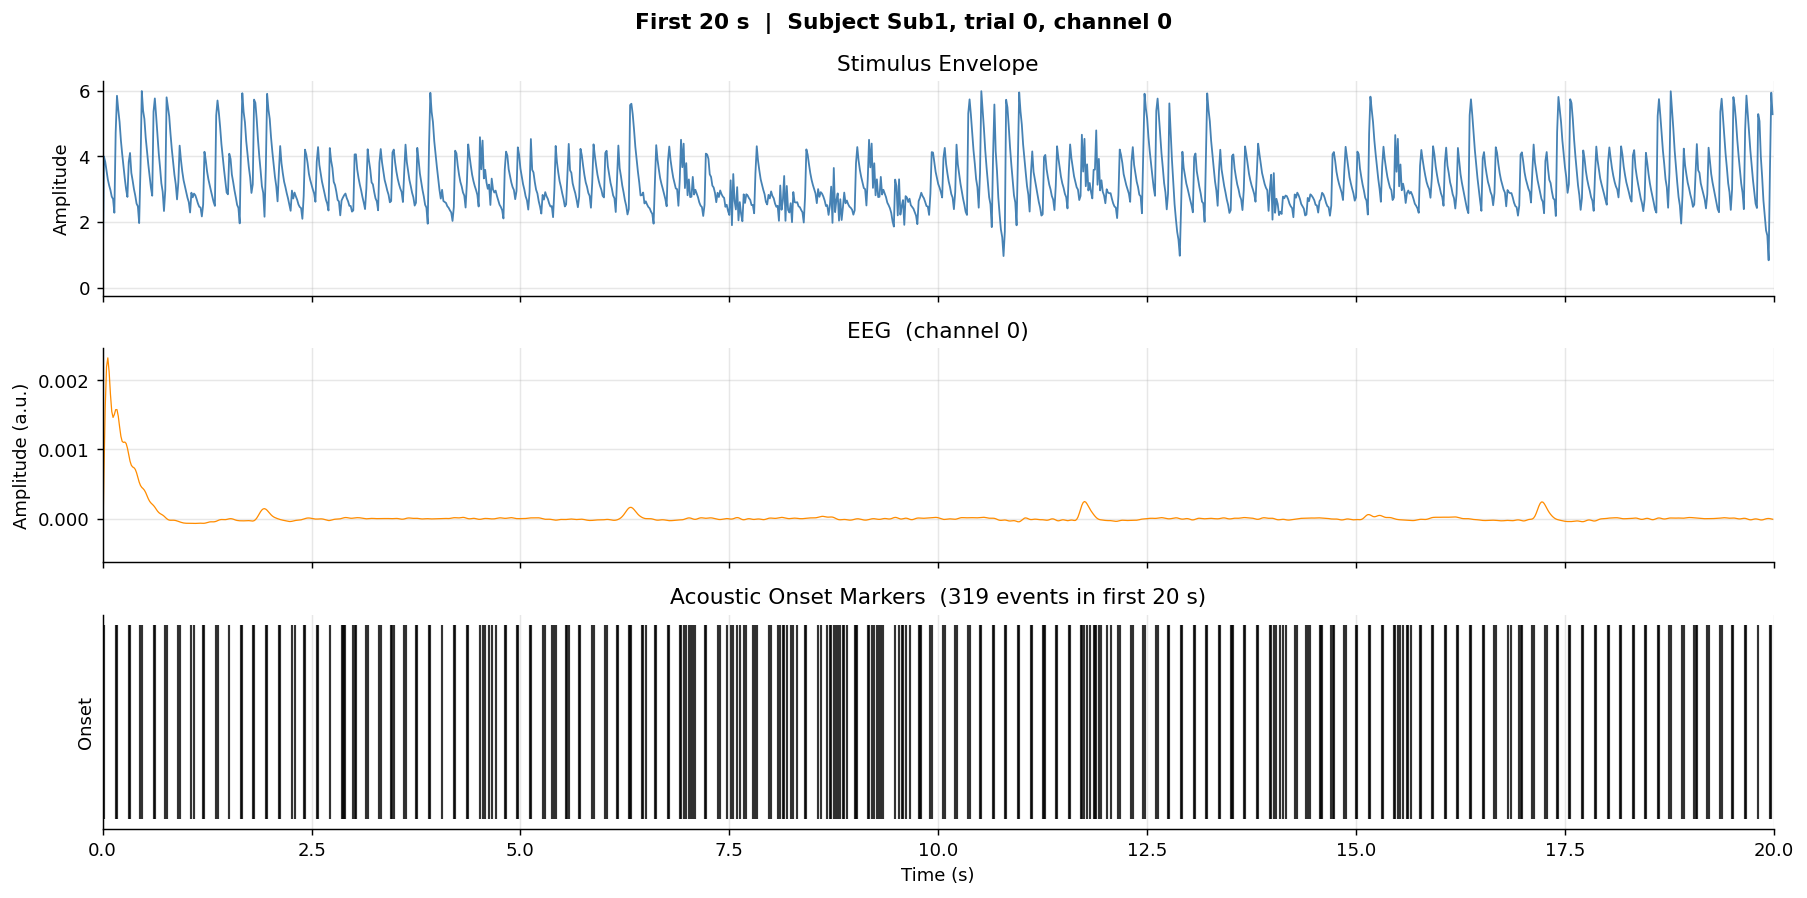

In [3]:

# ── First 10 s: envelope, EEG, acoustic onset markers ────────────────────────
#
# Plotting a short window rather than the full trial makes it easier to see
# whether the EEG and stimulus are plausibly synchronised.  The onset markers
# show exactly where acoustic energy rises sharply — if they line up with
# visible transients in the envelope and lagged responses in the EEG the
# temporal registration is healthy.

n_plot     = int(PLOT_DURATION_S * SFREQ)
t_plot     = t_s[:n_plot]
env_plot   = envelope[:n_plot]
eeg_plot   = eeg_ch[:n_plot]
onset_plot = onsets[:n_plot]

onset_mask  = onset_plot > 0
onset_times = t_plot[onset_mask]

fig, axes = plt.subplots(3, 1, figsize=(14, 7), sharex=True)
fig.suptitle(
    f'First {PLOT_DURATION_S:.0f} s  |  Subject {SUBJECT}, '
    f'trial {TRIAL_IDX}, channel {CHANNEL_IDX}',
    fontsize=12, fontweight='bold')

# Panel 1: stimulus envelope
axes[0].plot(t_plot, env_plot, color='steelblue', lw=1.0)
axes[0].set_ylabel('Amplitude')
axes[0].set_title('Stimulus Envelope')
axes[0].grid(True, alpha=0.3)

# Panel 2: EEG
axes[1].plot(t_plot, eeg_plot, color='darkorange', lw=0.7)
axes[1].set_ylabel('Amplitude (a.u.)')
axes[1].set_title(f'EEG  (channel {CHANNEL_IDX})')
axes[1].grid(True, alpha=0.3)

# Panel 3: onset markers as vertical unit lines
axes[2].vlines(onset_times, 0, 1, color='black', lw=1.2, alpha=0.8)
axes[2].set_ylabel('Onset')
axes[2].set_xlabel('Time (s)')
axes[2].set_title(
    f'Acoustic Onset Markers  '
    f'({len(onset_times)} events in first {PLOT_DURATION_S:.0f} s)')
axes[2].set_yticks([])
axes[2].set_xlim(0, PLOT_DURATION_S)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


Lag search window : +/-500 ms  (65 samples)
Peak correlation  : 0.0629  at lag 312.5 ms
Interpretation    : peak at 312.5 ms — outside 50-300 ms auditory range. Check alignment.


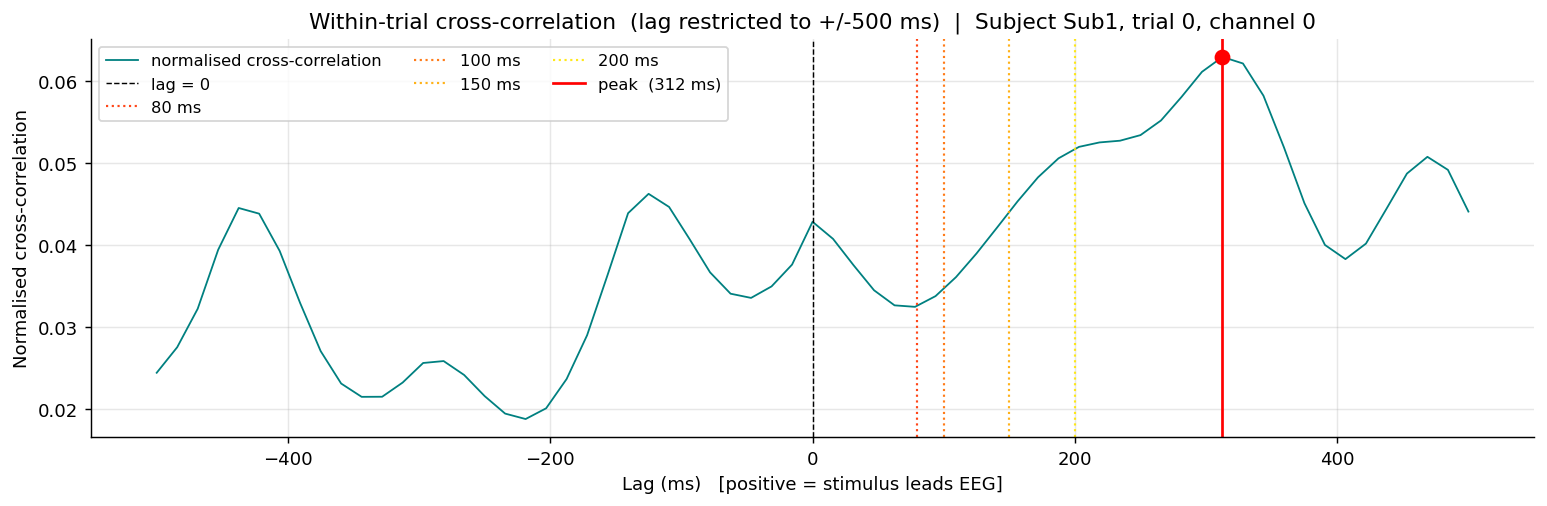

In [4]:

# ── Cross-correlation (within-trial, restricted to ±500 ms) ──────────────────
#
# Normalise by  std(eeg) * std(envelope) * N  so the result is dimensionless
# and comparable to a Pearson coefficient at each lag.
#
# Restricting the lag search to ±max_lag_sec avoids the common pitfall where
# the global maximum lands at a large negative or positive lag due to slow
# shared drift or edge artefacts — not because of a genuine auditory response.

corr = correlate(
    eeg_ch   - np.mean(eeg_ch),
    envelope - np.mean(envelope),
    mode='full'
)
corr /= (np.std(eeg_ch) * np.std(envelope) * len(envelope))

# Full lag axis:  centre index = n-1  corresponds to lag = 0
n        = len(eeg_ch)
lag_samp = np.arange(-(n - 1), n)
lag_ms   = lag_samp / SFREQ * 1000     # samples → ms

# Restrict lag search to ±max_lag_sec
max_lag_sec  = 0.5
max_lag      = int(max_lag_sec * SFREQ)   # samples

lag_center   = n - 1
search_start = lag_center - max_lag
search_end   = lag_center + max_lag + 1

corr_window   = corr[search_start:search_end]
lag_ms_window = lag_ms[search_start:search_end]

peak_idx    = int(np.argmax(corr_window))
peak_lag_ms = float(lag_ms_window[peak_idx])
peak_corr   = float(corr_window[peak_idx])

print(f'Lag search window : +/-{max_lag_sec * 1000:.0f} ms  '
      f'({2 * max_lag + 1} samples)')
print(f'Peak correlation  : {peak_corr:.4f}  at lag {peak_lag_ms:.1f} ms')
if 50 <= peak_lag_ms <= 300:
    print(f'Interpretation    : peak at {peak_lag_ms:.1f} ms — '
          f'consistent with auditory cortical latency (50-300 ms).')
else:
    print(f'Interpretation    : peak at {peak_lag_ms:.1f} ms — '
          f'outside 50-300 ms auditory range. Check alignment.')

# ── Plot ─────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 4))

ax.plot(lag_ms_window, corr_window, color='teal', lw=1.0,
        label='normalised cross-correlation')
ax.axvline(0, color='black', lw=0.8, linestyle='--', label='lag = 0')

aud_colors = plt.cm.autumn(np.linspace(0.2, 0.9, len(AUDITORY_LATENCIES_MS)))
for lat_ms, c in zip(AUDITORY_LATENCIES_MS, aud_colors):
    ax.axvline(lat_ms, color=c, lw=1.2, linestyle=':', alpha=0.9,
               label=f'{lat_ms} ms')

ax.axvline(peak_lag_ms, color='red', lw=1.5,
           label=f'peak  ({peak_lag_ms:.0f} ms)')
ax.scatter([peak_lag_ms], [peak_corr], color='red', s=60, zorder=5)

ax.set_xlabel('Lag (ms)   [positive = stimulus leads EEG]')
ax.set_ylabel('Normalised cross-correlation')
ax.set_title(
    f'Within-trial cross-correlation  (lag restricted to +/-{max_lag_sec * 1000:.0f} ms)  '
    f'|  Subject {SUBJECT}, trial {TRIAL_IDX}, channel {CHANNEL_IDX}')
ax.legend(fontsize=9, ncol=3)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


Loaded : Sub1_['envelope', 'onsets']_sklearn_ridge_acoustic_data.pkl
r mean : 0.0989   min=0.0415   max=0.1244
LOOCV folds stored : 30   (one per trial)
Coef shape per fold: (64, 104)   (n_channels x p)

Reconstructed prediction  (trial 0):
  Mean r (all channels) : -0.0670
  Channel 0 r           : -0.0328


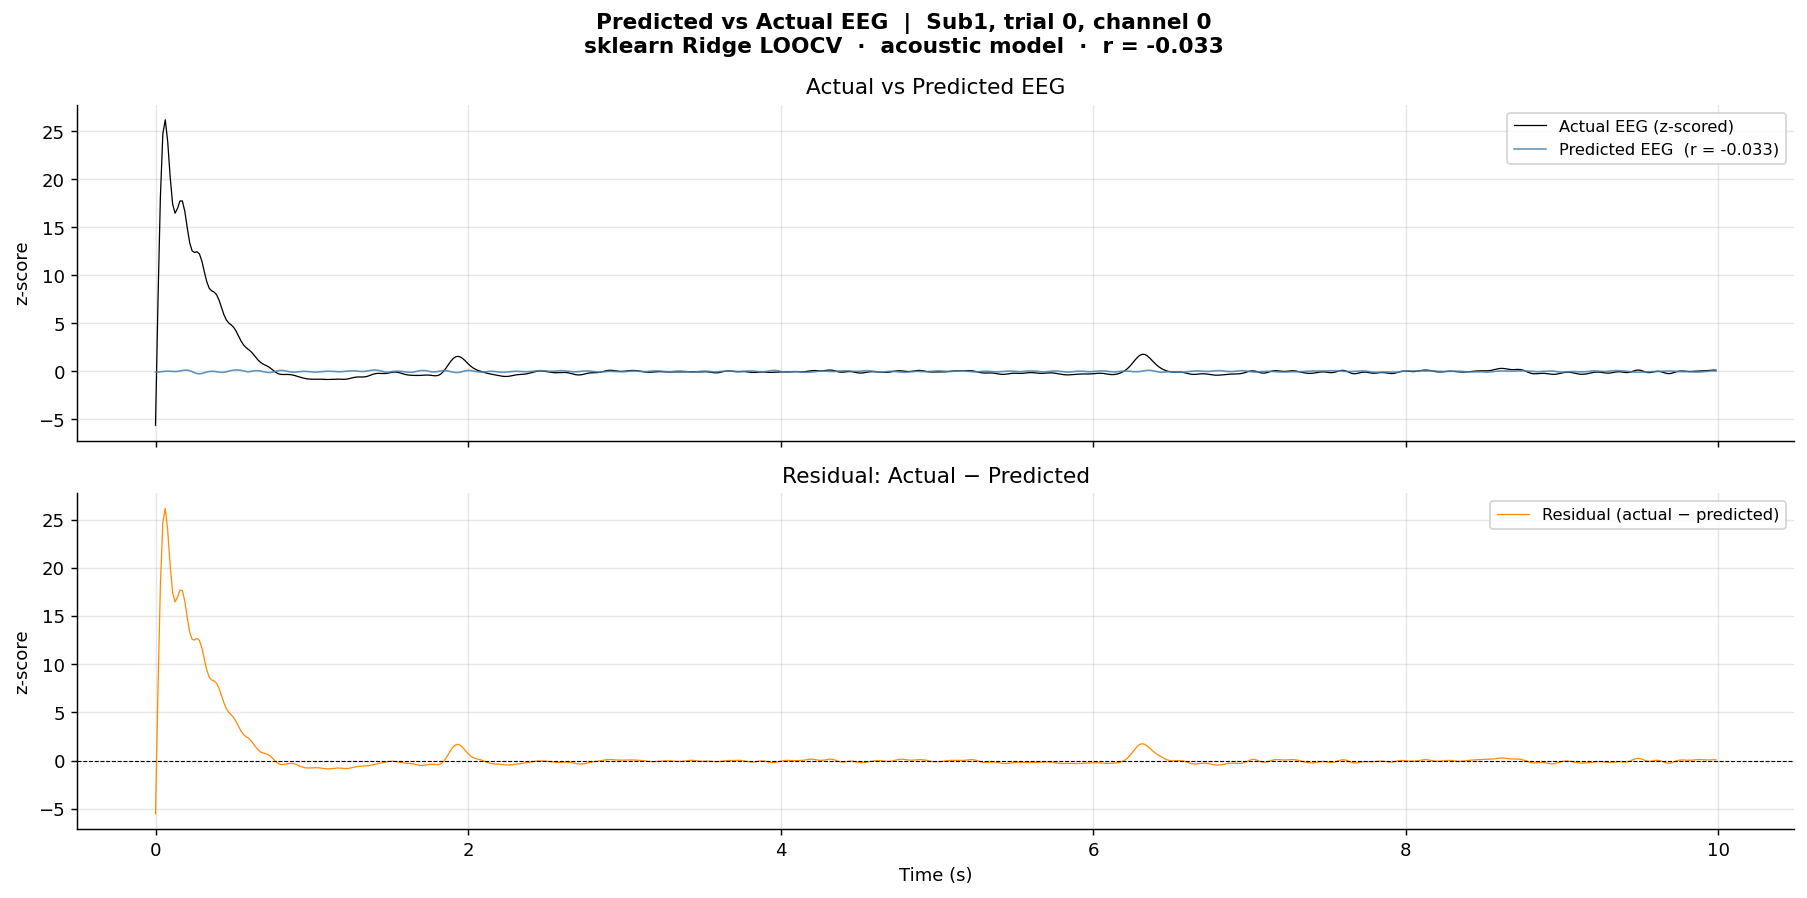

In [5]:
# ── Load sklearn ridge pickle and plot predicted vs actual EEG ──────────────
# Mirrors Section 7 of TRF_diagnostics.py.
#
# The sklearn pickle stores, per LOOCV fold i:
#   coefs[i]: (n_channels, p)  = W.T  where W was trained leaving out trial i
#
# Prediction for trial i:  Y_pred = Phi_i @ coefs[i].T
# where Phi_i is built from z-scored features at the same lag window.

from pathlib import Path
from scipy.stats import pearsonr
import eelbrain

TMIN       = -0.2
TMAX       =  0.600
PICKLE_DIR = Path('.').resolve() / 'pickles/encoding_2026-05-15'


def _zscore(x):
    """Z-score along axis=0 (works for 1-D and 2-D arrays)."""
    mu, sd = x.mean(axis=0), x.std(axis=0)
    return (x - mu) / np.where(sd > 0, sd, 1.0)


def _build_lag_matrix(x, tmin, tmax, sfreq):
    """Toeplitz lag matrix — identical to TRF_ridge_2.py."""
    n_lags  = int(round((tmax - tmin) * sfreq)) + 1
    lag_min = int(round(tmin * sfreq))
    lag_max = lag_min + n_lags - 1
    n       = len(x)
    x_pad   = np.concatenate([np.zeros(lag_max), x, np.zeros(max(0, -lag_min))])
    wins    = np.lib.stride_tricks.sliding_window_view(x_pad, n_lags)
    return np.ascontiguousarray(wins[:n, ::-1])


# ── Load pickle ───────────────────────────────────────────────────────────────
pkl_path = PICKLE_DIR / f"{SUBJECT}_['envelope', 'onsets']_sklearn_ridge_acoustic_data.pkl"
pkl_data = eelbrain.load.unpickle(pkl_path)
trf_cv   = pkl_data['trf_cv']

print(f'Loaded : {pkl_path.name}')
print(f'r mean : {trf_cv.r.mean():.4f}   min={trf_cv.r.x.min():.4f}   max={trf_cv.r.x.max():.4f}')
print(f'LOOCV folds stored : {len(trf_cv.coefs)}   (one per trial)')
print(f'Coef shape per fold: {trf_cv.coefs[0].shape}   (n_channels x p)')

# ── Reconstruct Phi for the held-out test trial ───────────────────────────────
# Features must be z-scored exactly as in TRF_ridge_2.py
Phi_test = np.hstack([
    _build_lag_matrix(_zscore(envelope), TMIN, TMAX, SFREQ),
    _build_lag_matrix(_zscore(onsets),   TMIN, TMAX, SFREQ),
])   # (n_times, 2 * n_lags)

# coefs[TRIAL_IDX] = W.T, shape (n_channels, p)
Y_pred = Phi_test @ trf_cv.coefs[TRIAL_IDX].T   # (n_times, n_channels)
Y_true = _zscore(eeg_arr)                        # (n_times, n_channels)

# Per-channel Pearson r
r_vals = np.array([pearsonr(Y_true[:, c], Y_pred[:, c])[0]
                   for c in range(Y_true.shape[1])])
print(f'\nReconstructed prediction  (trial {TRIAL_IDX}):')
print(f'  Mean r (all channels) : {r_vals.mean():.4f}')
print(f'  Channel {CHANNEL_IDX} r           : {r_vals[CHANNEL_IDX]:.4f}')

# ── Plot: predicted vs actual EEG (first 10 s, one channel) ──────────────────
ch     = CHANNEL_IDX
n_plot = min(len(Y_true), int(10 * SFREQ))
t_plot = np.arange(n_plot) / SFREQ

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
fig.suptitle(
    f'Predicted vs Actual EEG  |  {SUBJECT}, trial {TRIAL_IDX}, channel {CHANNEL_IDX}\n'
    f'sklearn Ridge LOOCV  ·  acoustic model  ·  r = {r_vals[ch]:.3f}',
    fontsize=12, fontweight='bold')

# Panel 1: overlay
axes[0].plot(t_plot, Y_true[:n_plot, ch], color='black',     lw=0.7,
             label='Actual EEG (z-scored)')
axes[0].plot(t_plot, Y_pred[:n_plot, ch], color='steelblue', lw=0.9, alpha=0.85,
             label=f'Predicted EEG  (r = {r_vals[ch]:.3f})')
axes[0].set_ylabel('z-score')
axes[0].set_title('Actual vs Predicted EEG')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

# Panel 2: residual
axes[1].plot(t_plot, Y_true[:n_plot, ch] - Y_pred[:n_plot, ch],
             color='darkorange', lw=0.7, label='Residual (actual − predicted)')
axes[1].axhline(0, color='black', lw=0.6, linestyle='--')
axes[1].set_ylabel('z-score')
axes[1].set_xlabel('Time (s)')
axes[1].set_title('Residual: Actual − Predicted')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


Loaded : Sub1_['envelope', 'onsets']_acoustic_data.pkl
r mean : 0.0145  min=-0.0078  max=0.0837
Kernel : shape=(64, 61)  lags -0.050→0.560 s  step=0.0100 s  (trained at 100 Hz)
✓ Loaded Non-musician (Subject Sub1)
  - 30 trials, 64 channels @ 512 Hz
100 Hz trial : EEG (15804, 64)  duration 158.04 s
Reconstructed : mean r=0.0011  channel 0 r=-0.0035


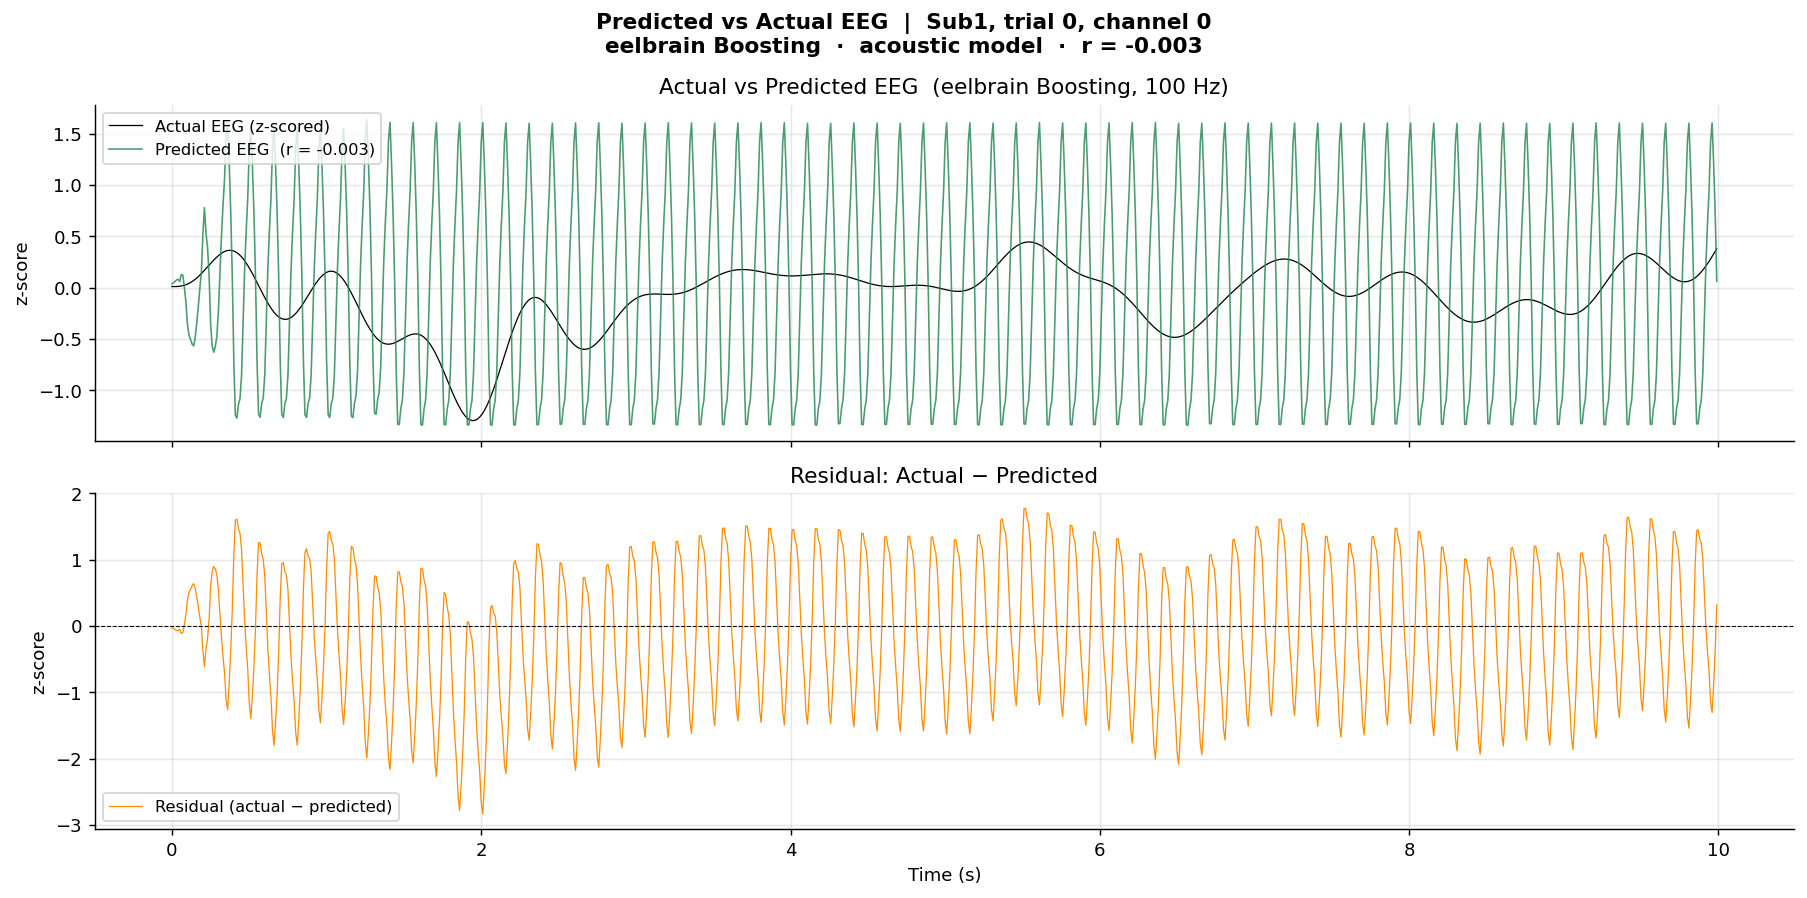

In [6]:
# ── Load eelbrain boosting pickle (encoding_2026-04-22) ─────────────────────
# Built by TRF_pickle_A_and_AM.py using eelbrain.boosting:
#   tmin=-0.05, tmax=0.55, basis=0.020, partitions=10, test=True, error='l1'
#   EEG at 100 Hz (native, no downsampling)
#   Envelope from WAV files via eelbrain.load.wav().envelope()
#   Features NOT manually z-scored — eelbrain scales internally
#
# y_pred is not stored in the pickle. Prediction is reconstructed by:
#   1. Reloading features at 100 Hz (WAV envelope, same preprocessing as training)
#   2. Normalising: x_scaled = (x - x_mean) / x_scale  (stored in the result)
#   3. Lag convolution: y_pred[t] = sum_k (L_k @ h_k.T) where L_k is the
#      Toeplitz lag matrix of feature k at the kernel's lag grid
#   4. Undo y-scaling: y_pred_raw = y_pred_scaled * y_scale + y_mean

from pathlib import Path
from scipy.stats import pearsonr
import eelbrain
import numpy as np

BOOST_SFREQ      = 100   # Hz — native rate used during training
BOOST_PICKLE_DIR = Path('.').resolve() / 'pickles/encoding_2026-04-22'

# ── Load pickle ───────────────────────────────────────────────────────────────
boost_pkl = BOOST_PICKLE_DIR / f"{SUBJECT}_['envelope', 'onsets']_acoustic_data.pkl"
boost_trf = eelbrain.load.unpickle(boost_pkl)['trf_cv']

print(f'Loaded : {boost_pkl.name}')
print(f'r mean : {boost_trf.r.mean():.4f}  '
      f'min={boost_trf.r.x.min():.4f}  max={boost_trf.r.x.max():.4f}')
print(f'Kernel : shape={boost_trf.h[0].shape}  '
      f'lags {boost_trf.h[0].time.tmin:.3f}→{boost_trf.h[0].time.tstop:.3f} s  '
      f'step={boost_trf.h[0].time.tstep:.4f} s  '
      f'(trained at {BOOST_SFREQ} Hz)')

# ── Reload trial data at 100 Hz to match training preprocessing ───────────────
# Cannot reuse the 64-Hz cell-2 data: different rate, different envelope source.
eeg_data_b = eeg_func.load_subject_raw_eeg(
    constants.EEG_DIR / f'data{SUBJECT}.mat', SUBJECT)
raw_b = eeg_func.create_mne_raw_from_loaded(eeg_data_b)
raw_b.filter(constants.LOW_FREQUENCY, constants.HIGH_FREQUENCY, n_jobs=1)

events_b = eeg_func.create_eelbrain_events(raw_b)

envelopes_b = []
for stim_id in events_b['event']:
    song_id = int(stim_id % 10) or 10
    wav_b   = eelbrain.load.wav(constants.WAV_DIR / f'{song_id}.wav')
    envelopes_b.append(eelbrain.resample(wav_b.envelope(), BOOST_SFREQ))

events_b['envelope'] = envelopes_b
events_b['onsets']   = [e.diff('time').clip(0) for e in envelopes_b]
events_b['duration'] = eelbrain.Var([e.time.tstop for e in envelopes_b])
events_b['eeg']      = eelbrain.load.mne.variable_length_epochs(
    events_b, 0, tstop='duration', decim=1, adjacency='auto')

# Extract the chosen trial
eeg_b   = events_b['eeg'][TRIAL_IDX].get_data(('sensor', 'time')).T   # (T, n_ch)
env_b   = envelopes_b[TRIAL_IDX].x
onset_b = events_b['onsets'][TRIAL_IDX].x
nb      = min(eeg_b.shape[0], len(env_b))
eeg_b, env_b, onset_b = eeg_b[:nb], env_b[:nb], onset_b[:nb]

print(f'100 Hz trial : EEG {eeg_b.shape}  duration {nb / BOOST_SFREQ:.2f} s')

# ── Apply TRF kernels to reconstruct prediction ───────────────────────────────
# Normalise features with stored global stats (same as eelbrain's internal scaling)
feats_scaled = [
    (env_b   - boost_trf.x_mean[0]) / boost_trf.x_scale[0],
    (onset_b - boost_trf.x_mean[1]) / boost_trf.x_scale[1],
]

# UTS has no .x attribute — compute lag times from scalar properties
h_time    = boost_trf.h[0].time
lag_times = np.arange(h_time.nsamples) * h_time.tstep + h_time.tmin
lag_samps = np.round(lag_times * BOOST_SFREQ).astype(int)  # e.g. [-5 … 56]

def _lag_matrix(x, lag_samps):
    """Toeplitz lag matrix: column j = x shifted by lag_samps[j] samples."""
    n = len(x)
    L = np.zeros((n, len(lag_samps)))
    for j, lag in enumerate(lag_samps):
        if lag >= 0:
            L[lag:, j] = x[:n - lag]
        else:
            ab = -lag
            L[:n - ab, j] = x[ab:]
    return L

n_ch_b   = eeg_b.shape[1]
Y_pred_b = np.zeros((nb, n_ch_b))

for k, (x_sc, h_k) in enumerate(zip(feats_scaled, boost_trf.h)):
    L     = _lag_matrix(x_sc, lag_samps)          # (nb, n_lags)
    h_arr = h_k.get_data(('sensor', 'time'))       # (n_ch, n_lags)
    Y_pred_b += L @ h_arr.T                        # (nb, n_ch)

# Undo eelbrain's internal y-scaling
Y_pred_b = Y_pred_b * boost_trf.y_scale.x + boost_trf.y_mean.x

# Z-score both for visual comparison (same convention as Section 7)
def _zsc(arr):
    mu, sd = arr.mean(axis=0), arr.std(axis=0)
    return (arr - mu) / np.where(sd > 0, sd, 1.0)

Y_pred_bz = _zsc(Y_pred_b)
Y_true_bz = _zsc(eeg_b)

r_b = np.array([pearsonr(Y_true_bz[:, c], Y_pred_bz[:, c])[0]
                for c in range(n_ch_b)])
print(f'Reconstructed : mean r={r_b.mean():.4f}  '
      f'channel {CHANNEL_IDX} r={r_b[CHANNEL_IDX]:.4f}')

# ── Plot: predicted vs actual EEG (first 10 s, one channel) ──────────────────
ch     = CHANNEL_IDX
n_plot = min(nb, int(10 * BOOST_SFREQ))
t_plot = np.arange(n_plot) / BOOST_SFREQ

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
fig.suptitle(
    f'Predicted vs Actual EEG  |  {SUBJECT}, trial {TRIAL_IDX}, channel {CHANNEL_IDX}\n'
    f'eelbrain Boosting  ·  acoustic model  ·  r = {r_b[ch]:.3f}',
    fontsize=12, fontweight='bold')

# Panel 1: overlay
axes[0].plot(t_plot, Y_true_bz[:n_plot, ch], color='black', lw=0.7,
             label='Actual EEG (z-scored)')
axes[0].plot(t_plot, Y_pred_bz[:n_plot, ch], color='seagreen', lw=0.9, alpha=0.85,
             label=f'Predicted EEG  (r = {r_b[ch]:.3f})')
axes[0].set_ylabel('z-score')
axes[0].set_title('Actual vs Predicted EEG  (eelbrain Boosting, 100 Hz)')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

# Panel 2: residual
axes[1].plot(t_plot, Y_true_bz[:n_plot, ch] - Y_pred_bz[:n_plot, ch],
             color='darkorange', lw=0.7, label='Residual (actual − predicted)')
axes[1].axhline(0, color='black', lw=0.6, linestyle='--')
axes[1].set_ylabel('z-score')
axes[1].set_xlabel('Time (s)')
axes[1].set_title('Residual: Actual − Predicted')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Loaded: Sub2_['envelope', 'onsets']_conv_nonlinear_acoustic_data.pkl
top-level keys: ['trf_cv', 'Y_pred', 'Y_true']
Y_true shape: (307527, 64)
Y_pred shape: (307527, 64)
Mean r (all channels): 0.5086


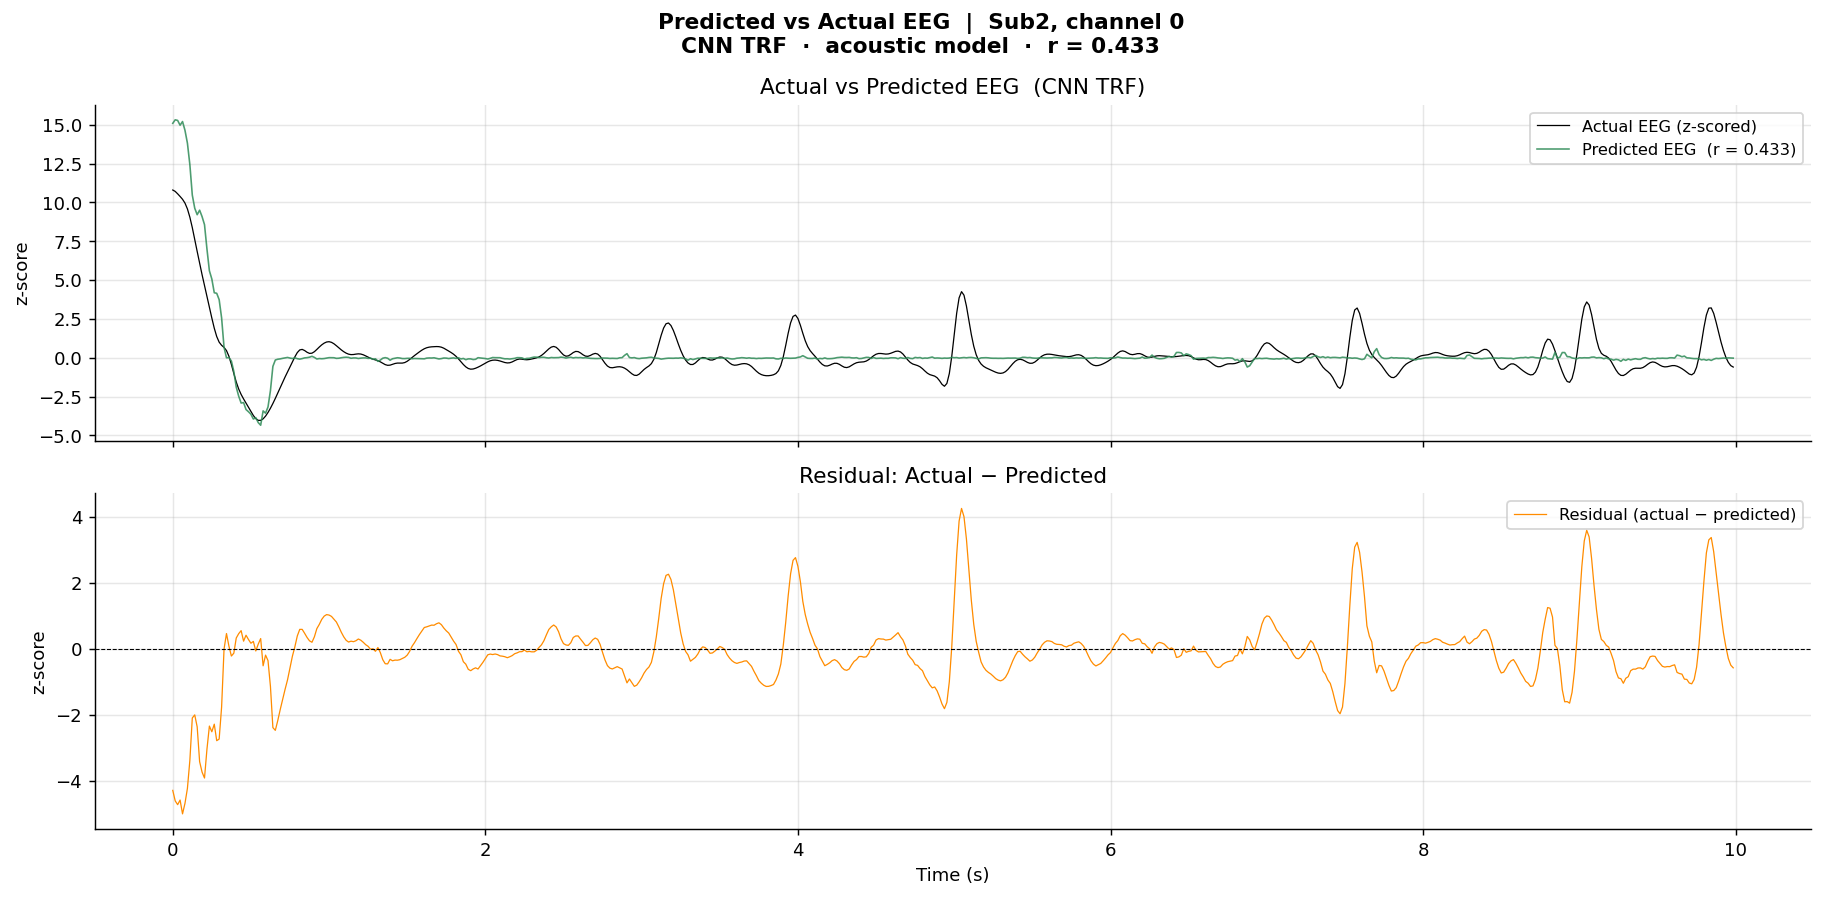

In [12]:
# ── Load CNN TRF pickle and plot predicted vs actual EEG ──────────────
CNN_PICKLE_DIR = Path('.').resolve() / 'pickles/encoding_2026-06-05'
cnn_pkl = CNN_PICKLE_DIR / f"{SUBJECT}_['envelope', 'onsets']_conv_nonlinear_acoustic_data.pkl"
cnn_data = eelbrain.load.unpickle(cnn_pkl)

print(f'Loaded: {cnn_pkl.name}')
print('top-level keys:', list(cnn_data.keys()))

Y_true_all = cnn_data['Y_true']   # (T_total, 64), z-scored per trial
Y_pred_all = cnn_data['Y_pred']

print('Y_true shape:', Y_true_all.shape)
print('Y_pred shape:', Y_pred_all.shape)

r_vals = np.array([pearsonr(Y_true_all[:, c], Y_pred_all[:, c])[0]
                   for c in range(Y_true_all.shape[1])])
print(f'Mean r (all channels): {r_vals.mean():.4f}')

# ── Plot ──────────────────────────────────────────────────────────────
ch = CHANNEL_IDX if CHANNEL_IDX < Y_true_all.shape[1] else 0
n_plot = min(len(Y_true_all), int(10 * SFREQ))
t_plot = np.arange(n_plot) / SFREQ

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
fig.suptitle(
    f'Predicted vs Actual EEG  |  {SUBJECT}, channel {ch}\n'
    f'CNN TRF  ·  acoustic model  ·  r = {r_vals[ch]:.3f}',
    fontsize=12, fontweight='bold')

axes[0].plot(t_plot, Y_true_all[:n_plot, ch], color='black', lw=0.7, label='Actual EEG (z-scored)')
axes[0].plot(t_plot, Y_pred_all[:n_plot, ch], color='seagreen', lw=0.9, alpha=0.85,
             label=f'Predicted EEG  (r = {r_vals[ch]:.3f})')
axes[0].set_ylabel('z-score')
axes[0].set_title('Actual vs Predicted EEG  (CNN TRF)')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

axes[1].plot(t_plot, Y_true_all[:n_plot, ch] - Y_pred_all[:n_plot, ch],
             color='darkorange', lw=0.7, label='Residual (actual − predicted)')
axes[1].axhline(0, color='black', lw=0.6, linestyle='--')
axes[1].set_ylabel('z-score')
axes[1].set_xlabel('Time (s)')
axes[1].set_title('Residual: Actual − Predicted')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()